In [0]:
# %skip
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.9/281.9 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 73.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Not uninstalling protobuf at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b487b42c-3d22-43f2-ba59-5a4ad7ba54a4
    Can't uninstall 'protobuf'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.28.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4

In [0]:

# %skip
%restart_python

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [0]:
# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Check shapes
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


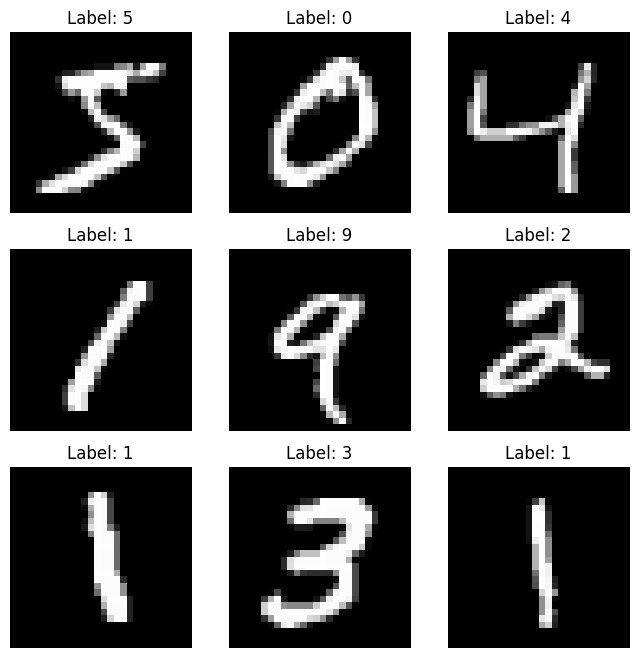

In [0]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

In [0]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(y_train.shape)  # should be (60000, 10)

(60000, 10)


In [0]:
model = Sequential()

# First Conv Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# Second Conv Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-b487b42c-3d22-43f2-ba59-5a4ad7ba54a4/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10


W0000 00:00:1775636351.695004    3472 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


  7/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.1462 - loss: 2.2931

W0000 00:00:1775636352.943988    3621 cpu_allocator_impl.cc:82] Allocation of 17981568 exceeds 10% of free system memory.
W0000 00:00:1775636352.945585    3623 cpu_allocator_impl.cc:82] Allocation of 17981568 exceeds 10% of free system memory.
W0000 00:00:1775636352.976576    3623 cpu_allocator_impl.cc:82] Allocation of 17981568 exceeds 10% of free system memory.
W0000 00:00:1775636352.976614    3620 cpu_allocator_impl.cc:82] Allocation of 17981568 exceeds 10% of free system memory.


750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.9135 - loss: 0.2809 - val_accuracy: 0.9801 - val_loss: 0.0702
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9722 - loss: 0.0952 - val_accuracy: 0.9858 - val_loss: 0.0484
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9789 - loss: 0.0668 - val_accuracy: 0.9882 - val_loss: 0.0420
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9831 - loss: 0.0565 - val_accuracy: 0.9885 - val_loss: 0.0436
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9858 - loss: 0.0465 - val_accuracy: 0.9902 - val_loss: 0.0351
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9875 - loss: 0.0399 - val_accuracy: 0.9898 - val_loss: 0.0354
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9903 - val_loss: 0.0395
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9900 - loss: 0.0300 - val_accurac

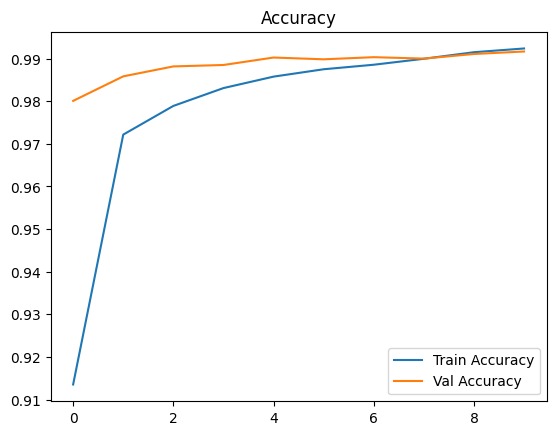

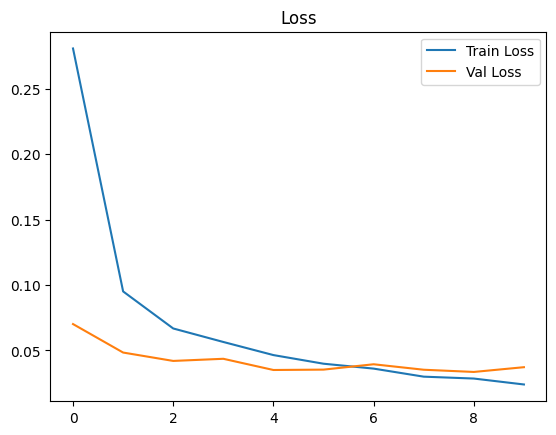

In [0]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [0]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9924 - loss: 0.0266
Test Accuracy: 0.9923999905586243


In [0]:
model.save("mnist_cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction: 8


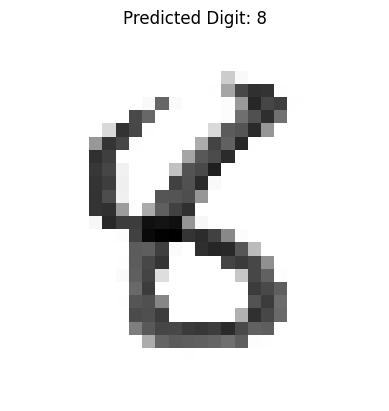

In [0]:
from tensorflow.keras.preprocessing import image

img_path = "/Workspace/Users/issackureekkattil@gmail.com/sample/sample2.png"

# Load image (change path)
img = image.load_img(img_path, target_size=(28,28), color_mode='grayscale')
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Reshape
img_array = img_array.reshape(1,28,28,1)

# Predict1
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)

plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')

print("Prediction:", predicted_digit)